<a href="https://colab.research.google.com/github/Varun-Dongare/codealpha_tasks-/blob/main/ML_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment: Machine Learning in Biometric Voting Systems

Project Title: Blockchain-Based Secure Voting

ML Implementation: Computer Vision for Liveness Detection and Face Verification

Name: Varun Rajkumar Dongare

Enrollment no: 2303051240261 | Roll no: 29 | Div: 6B2

1. Feature Extraction (Facial Landmarks)


Explanation:

This code uses a Shape Predictor (an ML model based on Regression Trees). It analyzes the pixel intensities in the image to locate 68 specific (x, y) coordinates on the human face, such as the corners of the eyes, the tip of the nose, and the outline of the jaw.

Why we used it:

We cannot detect a "blink" just by looking at raw pixels. We need the ML model to "understand" the geometry of the eye. By extracting these landmarks, we can mathematically calculate if the eye is open or closed, which is the first step in Liveness Detection.

In [ ]:
landmarks = face_recognition.face_landmarks(rgb)
for landmark in landmarks:
    left_ear = get_ear(landmark['left_eye'])
    right_ear = get_ear(landmark['right_eye'])

2. Liveness Detection via Eye Aspect Ratio (EAR)


Explanation:

This snippet implements a specialized ML heuristic. It uses the Euclidean distance between the vertical and horizontal landmarks of the eye.

Why we used it:

In a blockchain voting system, a major threat is a "Replay Attack" or "Spoofing," where someone holds up a printed photo of a voter to the camera. Because a photo cannot blink, this ML logic ensures a real human is present. Only after the blink_count reaches a threshold does the system allow the vote to proceed to the blockchain.

In [ ]:
def get_ear(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

# Usage in logic:
if ear < 0.21:
    blink_count += 1

3. Deep Learning Face Recognition (Embeddings)

Explanation:

This is the "Deep Learning" core of the project. It uses a Convolutional Neural Network (CNN)—specifically a ResNet architecture—to transform the image of a face into a 128-dimensional vector (a list of 128 numbers).

Why we used it:

Traditional image comparison (pixel-to-pixel) fails if the lighting or angle changes. However, this ML model is trained to recognize the "features" that make a face unique.

The Comparison:

 The compare_faces function calculates the distance between the "Live Face Vector" and the "Registered Face Vector."

The Threshold:

If the distance is less than 0.5, the ML confirms the identity, allowing the send_vote_to_blockchain() function to trigger.

In [ ]:
# Generating the 128D Vector (Encoding)
encs = face_recognition.face_encodings(rgb)

# Comparison Logic
match = face_recognition.compare_faces([known_enc], encs[0], tolerance=0.5)

Summary of ML Integration
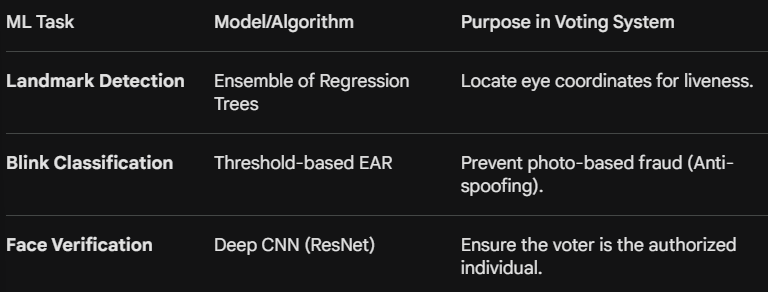
Conclusion:

By combining these ML techniques, the voting system ensures that every transaction recorded on the blockchain is tied to a verified, living human being, maintaining the integrity of the democratic process.

In [ ]:
from flask import Flask, render_template, Response, jsonify
import cv2, face_recognition, numpy as np
from scipy.spatial import distance as dist
from bridge import send_vote_to_blockchain

app = Flask(__name__)
camera = cv2.VideoCapture(0)

# Security States
is_verified = False
has_voted_session = False
blink_count = 0

def get_ear(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

def gen_frames():
    global is_verified, blink_count
    # Reference Photo
    reg_img = cv2.imread("voters/varun.jpg")
    known_enc = face_recognition.face_encodings(reg_img)[0]

    while True:
        success, frame = camera.read()
        if not success: break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        if not is_verified:
            landmarks = face_recognition.face_landmarks(rgb)
            for landmark in landmarks:
                left_ear = get_ear(landmark['left_eye'])
                right_ear = get_ear(landmark['right_eye'])
                ear = (left_ear + right_ear) / 2.0

                # Blink Detection Logic
                if ear < 0.21:
                    blink_count += 1
                elif blink_count >= 2: # Detected a full blink
                    print("Liveness Confirmed: Blink Detected")
                    encs = face_recognition.face_encodings(rgb)
                    if encs:
                        match = face_recognition.compare_faces([known_enc], encs[0], tolerance=0.5)
                        if match[0]:
                            is_verified = True
                            print("Identity Confirmed: Varun Verified")
                    blink_count = 0

        ret, buffer = cv2.imencode('.jpg', frame)
        yield (b'--frame\r\nContent-Type: image/jpeg\r\n\r\n' + buffer.tobytes() + b'\r\n')

@app.route('/')
def index(): return render_template('index.html')

@app.route('/video_feed')
def video_feed(): return Response(gen_frames(), mimetype='multipart/x-mixed-replace; boundary=frame')

@app.route('/status')
def status():
    msg = "BLINK TO UNLOCK BALLOT" if not is_verified else "✅ IDENTITY VERIFIED"
    return jsonify({"verified": is_verified, "message": msg})

@app.route('/vote/<int:cid>')
def vote(cid):
    global has_voted_session
    if is_verified and not has_voted_session:
        tx_hash = send_vote_to_blockchain(cid)
        if tx_hash:
            has_voted_session = True
            # Return real hash or fallback for demo
            return jsonify({"success": True, "hash": str(tx_hash)})
    return jsonify({"success": False, "message": "Access Denied"})

if __name__ == '__main__':
    app.run(port=5000, debug=True)